In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Adult dataset directly from URL — no AIF360 needed
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race',
    'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
    'native-country', 'income'
]

df = pd.read_csv(url, names=columns, 
                  na_values=' ?', 
                  skipinitialspace=True)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
# ── CELL 2: Basic Info and Missing Values ─────────
print("=== DATASET SHAPE ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== DATASET SHAPE ===
Rows: 32561
Columns: 15

=== MISSING VALUES ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

=== DATA TYPES ===
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object


=== INCOME DISTRIBUTION ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Percentage:
income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


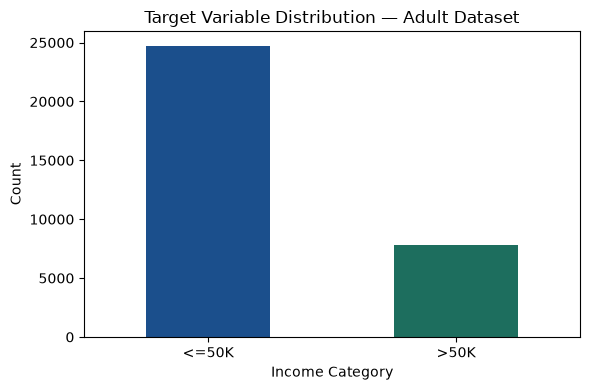

In [3]:
# ── CELL 3: Target Variable Distribution ──────────
print("=== INCOME DISTRIBUTION ===")
print(df['income'].value_counts())
print("\nPercentage:")
print(df['income'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
df['income'].value_counts().plot(kind='bar', color=['#1B4F8C','#1D6E5E'])
plt.title('Target Variable Distribution — Adult Dataset')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== INCOME >50K BY GENDER ===
sex
Female    10.95
Male      30.57
Name: income, dtype: float64


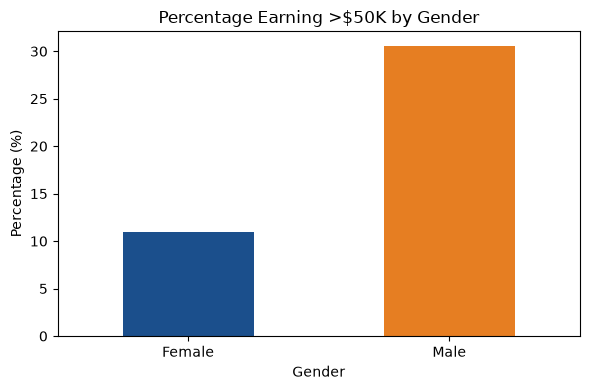

In [4]:
# ── CELL 4: First Bias Signal — Income by Gender ──
print("=== INCOME >50K BY GENDER ===")
gender_income = df.groupby('sex')['income'].apply(
    lambda x: (x=='>50K').mean()*100).round(2)
print(gender_income)

plt.figure(figsize=(6,4))
gender_income.plot(kind='bar', color=['#1B4F8C','#E67E22'])
plt.title('Percentage Earning >$50K by Gender')
plt.ylabel('Percentage (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== INCOME >50K BY RACE ===
race
Amer-Indian-Eskimo    11.58
Asian-Pac-Islander    26.56
Black                 12.39
Other                  9.23
White                 25.59
Name: income, dtype: float64


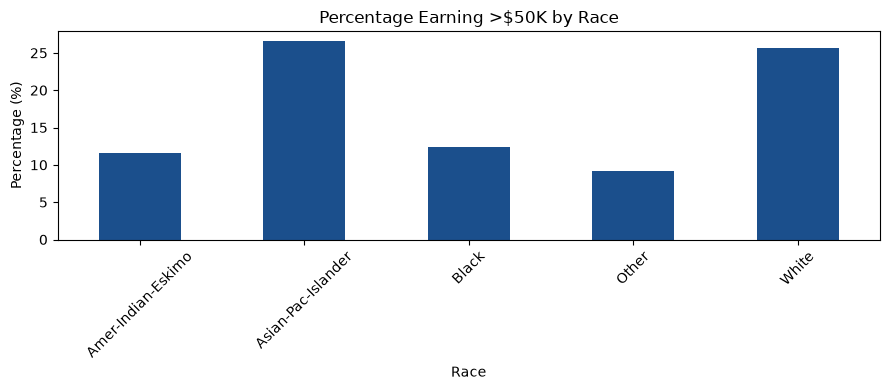

In [5]:
# ── CELL 5: Income by Race ────────────────────────
print("=== INCOME >50K BY RACE ===")
race_income = df.groupby('race')['income'].apply(
    lambda x: (x=='>50K').mean()*100).round(2)
print(race_income)

plt.figure(figsize=(9,4))
race_income.plot(kind='bar', color='#1B4F8C')
plt.title('Percentage Earning >$50K by Race')
plt.ylabel('Percentage (%)')
plt.xlabel('Race')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()